# Preprocesamiento y Modelado
## Clasificación de Niveles de Obesidad

Se usa el archivo `ObesityDataSet_limpio_m.csv` generado al final de nuestro EDA.

In [46]:
# Importar librerías

#  Librerías base 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#  Preprocesamiento y Pipeline 
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#  Modelos 
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

#  Métricas 
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

#  Guardar modelo 
import joblib
import os

#  Configuración visual 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('Librerías importadas correctamente')

Librerías importadas correctamente


### Cargar el dataset del EDA
Cargamos el CSV `ObesityDataSet_limpio_m.csv`. Nuestro EDA ya se encargó de filtrar la metadata inútil y los outliers extremos de la edad.

In [47]:
# Cargamos el dataset limpio generado por el EDA
df = pd.read_csv('../data/processed/ObesityDataSet_limpio_m.csv')

print(f'Dataset cargado')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\nDistribución del target:')
print(df['nobeyesdad'].value_counts())
display(df.head(10))

Dataset cargado
Dimensiones: 2111 filas x 17 columnas

Distribución del target:
nobeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


,gender,age,height,weight,family_history_with_overweight,favc,fcvc,ncp,caec,smoke,ch2o,scc,faf,tue,calc,mtrans,nobeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


### Preparación del Target
**¿Por qué hay que encodear?**
Los modelos de Machine Learning matemáticos (como XGBoost) solo entienden números. Textos como 'Obesity_Type_I' no pueden ser procesados. Usaremos `LabelEncoder` para asignar un número (del 0 al 6) a cada clase.

In [48]:
#  Encodear el target 
le = LabelEncoder()

# Asignamos números a las clases
df['target_encoded'] = le.fit_transform(df['nobeyesdad'])

# Guardamos el mapeo para documentarlo
mapeo_clases = dict(zip(le.classes_, le.transform(le.classes_)))

print('Target codificado correctamente')
for nombre, num in mapeo_clases.items():
    print(f'   {nombre}: {num}')

Target codificado correctamente
   Insufficient_Weight: 0
   Normal_Weight: 1
   Obesity_Type_I: 2
   Obesity_Type_II: 3
   Obesity_Type_III: 4
   Overweight_Level_I: 5
   Overweight_Level_II: 6


### Split Train / Test
**¿Por qué dividir el dataset ahora?**
Para evitar el *Data Leakage* (fuga de datos). Todo preprocesamiento matemático (como escalar promedios) debe hacerse solo con el grupo de *Train* (80%). El *Test* (20%) se guarda intacto para simular pacientes reales del futuro.
Usaremos `stratify=y` para asegurar que todas las clases mantengan su proporción.

In [49]:
#  Split 
X = df.drop(columns=['nobeyesdad', 'target_encoded'])
y = df['target_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% para test
    random_state=42,      # Semilla para reproducibilidad
    stratify=y            # Mantener proporciones de las 7 clases
)

print(f'Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 1688 filas (80.0%)
Test:  423 filas (20.0%)


### Pipeline de Preprocesamiento (Imputar, Escalar, Encodear)
En lugar de hacerlo manualmente, creamos una "tubería" (Pipeline) de automatización.
* **Numéricas:** Rellenamos nulos por precaución + `StandardScaler` (iguala escalas, crítico para KNN).
* **Categóricas:** Rellenamos nulos + `OneHotEncoder` (Transforma texto en variables binarias 0/1).

In [50]:
# 1. Separar columnas por tipo
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# 2. Definir transformadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

# 3. Unificar en un Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Pipeline preprocesador construido. Escalará y transformará todo automáticamente.")

Pipeline preprocesador construido. Escalará y transformará todo automáticamente.


### Evaluación: Modelos Baseline y Avanzados
Entrenaremos un modelo basado en distancias espaciales (KNN) como base y un modelo de gradiente (XGBoost) como avanzado. 
Usamos `f1_macro` para que las métricas valoren por igual todas las clases de obesidad.

In [51]:
def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te, cv=5):
    """Entrena el Pipeline completo y devuelve métricas multiclase."""
    
    # Ensamblar Pipeline: Preprocesador + Modelo
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', modelo)])
    
    # Entrenar
    pipe.fit(X_tr, y_tr)
    
    # Predecir
    y_pred = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te) # Probabilidades para ROC-AUC
    
    # Validación cruzada
    cv_scores = cross_val_score(
        pipe, X_tr, y_tr,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring='f1_macro'
    )
    
    return {
        'Modelo'     : nombre,
        'Accuracy'   : accuracy_score(y_te, y_pred),
        'Precision'  : precision_score(y_te, y_pred, average='macro'),
        'Recall'     : recall_score(y_te, y_pred, average='macro'),
        'F1_Macro'   : f1_score(y_te, y_pred, average='macro'),
        'ROC-AUC'    : roc_auc_score(y_te, y_prob, multi_class='ovr'),
        'CV F1 Media': cv_scores.mean(),
        'CV F1 Std'  : cv_scores.std(),
        'pipeline'   : pipe
    }

#  BASELINE: KNN (K-Nearest Neighbors) 
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
res_knn = evaluar_modelo('KNN_Baseline', knn_model, X_train, X_test, y_train, y_test)

#  AVANZADO: XGBoost 
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
res_xgb = evaluar_modelo('XGBoost', xgb_model, X_train, X_test, y_train, y_test)

print("Modelos entrenados y evaluados.")

Modelos entrenados y evaluados.


### Optimización de Hiperparámetros (XGBoost)
Buscamos la combinación óptima de árboles y profundidad para exprimir su máximo potencial y controlar que no memorice (*overfitting*).

In [52]:
param_dist = {
    'classifier__n_estimators':[100, 200, 300],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate':[0.01, 0.05, 0.1]
}

# Pipeline temporal para la búsqueda
pipe_search = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', XGBClassifier(random_state=42, n_jobs=1))])

# Búsqueda aleatoria de hiperparámetros
xgb_search = RandomizedSearchCV(
    estimator=pipe_search,
    param_distributions=param_dist,
    n_iter=10,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Mejores hiperparámetros XGBoost:")
print(xgb_search.best_params_)

# Extraer y evaluar el mejor modelo
xgb_opt_pipe = xgb_search.best_estimator_

y_pred_opt = xgb_opt_pipe.predict(X_test)
y_prob_opt = xgb_opt_pipe.predict_proba(X_test)

res_xgb_opt = {
    'Modelo': 'XGBoost_Optimizado',
    'Accuracy': accuracy_score(y_test, y_pred_opt),
    'Precision': precision_score(y_test, y_pred_opt, average='macro'),
    'Recall': recall_score(y_test, y_pred_opt, average='macro'),
    'F1_Macro': f1_score(y_test, y_pred_opt, average='macro'),
    'ROC-AUC': roc_auc_score(y_test, y_prob_opt, multi_class='ovr'),
    'CV F1 Media': xgb_search.best_score_,
    'CV F1 Std': xgb_search.cv_results_['std_test_score'][xgb_search.best_index_],
    'pipeline': xgb_opt_pipe
}

Fitting 5 folds for each of 10 candidates, totalling 50 fits


Traceback (most recent call last):
  File "/home/mar/Desktop/ProyectoF5/p7_g1_multiclase/.venv/lib/python3.13/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L2Rldi9zaG0vam9ibGliX21lbW1hcHBpbmdfZm9sZGVyXzg0MDk1XzU3ZmMwY2UyY2JiZTQwNTNiZWYyOThmODU5NWE1YTc1XzQzOWRkNjEzMjMyNTQzZjc4MmU3ZWU0ZWZlNjI2NmMw"}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/home/mar/Desktop/ProyectoF5/p7_g1_multiclase/.venv/lib/python3.13/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L2Rldi9zaG0vam9ibGliX21lbW1hcHBpbmdfZm9sZGVyXzg0MDk1X

Mejores hiperparámetros XGBoost:
{'classifier__n_estimators': 300, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05}


### Comparación de modelos y selección del mejor
Consolidamos las métricas en una tabla y un gráfico para elegir el ganador oficial.

Comparación de Modelos:


,Accuracy,Precision,Recall,F1_Macro,ROC-AUC,CV F1 Media,CV F1 Std
Modelo,,,,,,,
KNN_Baseline,0.8534,0.8447,0.8479,0.8397,0.9680,0.8134,0.0175
XGBoost,0.9456,0.9464,0.9436,0.9440,0.9966,0.9665,0.0042
XGBoost_Optimizado,0.9574,0.9571,0.9553,0.9559,0.9966,0.9696,0.0051


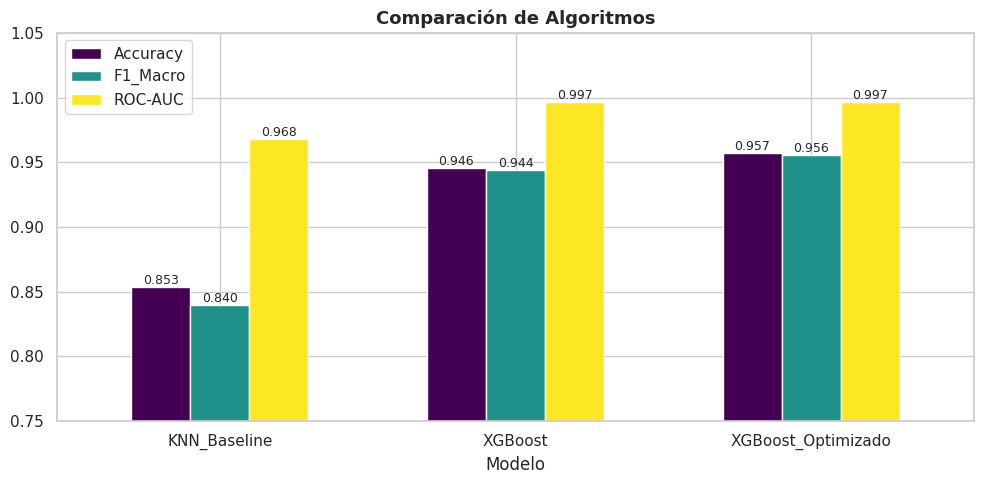


 Mejor modelo general: XGBoost_Optimizado


In [53]:
resultados =[res_knn, res_xgb, res_xgb_opt]
cols_metricas =['Modelo','Accuracy','Precision','Recall','F1_Macro','ROC-AUC','CV F1 Media','CV F1 Std']
df_resultados = pd.DataFrame(resultados)[cols_metricas].set_index('Modelo').round(4)

print('Comparación de Modelos:')
display(df_resultados)

# Gráfico comparativo
metricas_plot =['Accuracy', 'F1_Macro', 'ROC-AUC']
fig, ax = plt.subplots(figsize=(10, 5))
df_resultados[metricas_plot].plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white', width=0.6)
ax.set_title('Comparación de Algoritmos', fontsize=13, fontweight='bold')
ax.set_ylim(0.75, 1.05)
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.show()

mejor = df_resultados['F1_Macro'].idxmax()
print(f'\n Mejor modelo general: {mejor}')

### Análisis del Modelo Ganador
Para confirmar la utilidad clínica del modelo, revisaremos la **Matriz de Confusión** (qué errores comete y entre qué clases) y su **Feature Importance** (qué variables miró para tomar la decisión).

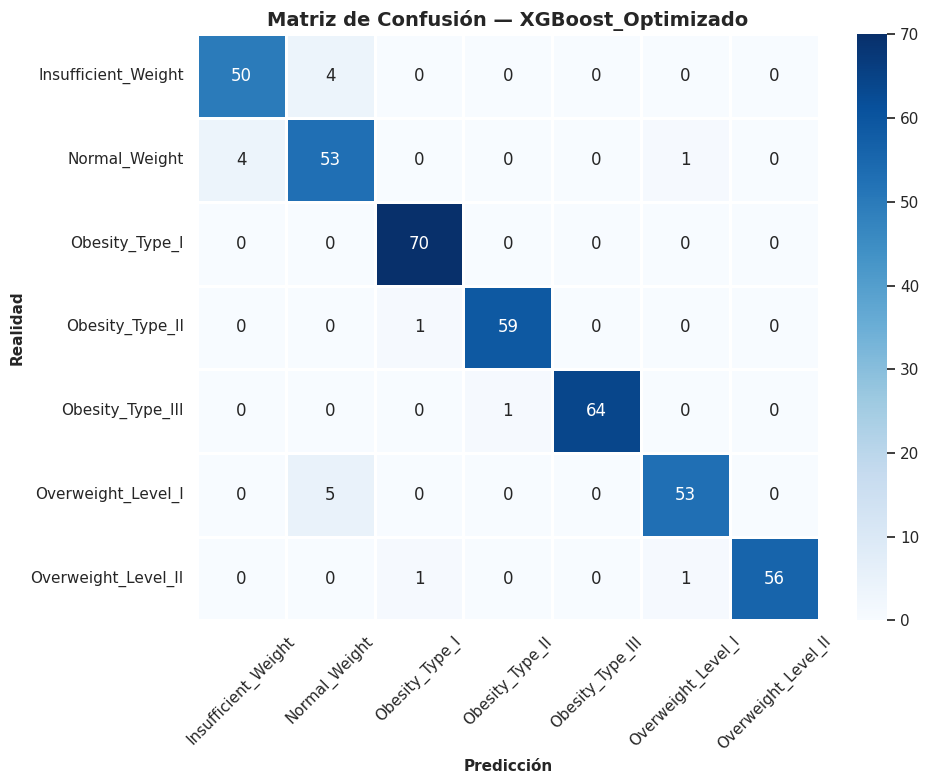

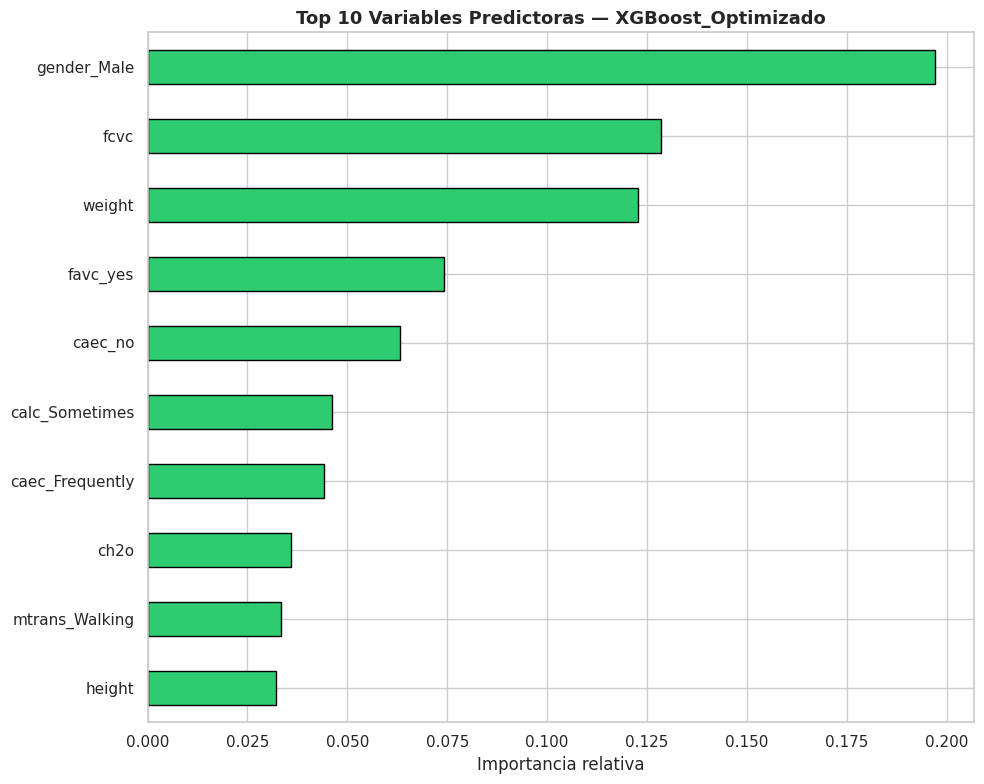

In [ ]:
# Selección automática del ganador
pipe_ganador = next(r['pipeline'] for r in resultados if r['Modelo'] == mejor)
y_pred_final = pipe_ganador.predict(X_test)

#  Matriz de confusión 
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=1)
plt.xlabel('Predicción', fontsize=11, fontweight='bold')
plt.ylabel('Realidad', fontsize=11, fontweight='bold')
plt.title(f'Matriz de Confusión — {mejor}', fontweight='bold', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  Feature Importance 
# Extraer nombres creados por OneHotEncoder
cat_feat_names = pipe_ganador.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_feat_names = list(numeric_cols) + list(cat_feat_names)

modelo_xgboost = pipe_ganador.named_steps['classifier']
importancias = pd.Series(modelo_xgboost.feature_importances_, index=all_feat_names).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importancias.tail(10).plot(kind='barh', color='#2ecc71', edgecolor='black')
plt.xlabel('Importancia relativa')
plt.title(f'Top 10 Variables Predictoras — {mejor}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Guardar el modelo
Al usar un *Pipeline*, el objeto exportado contiene todo: la media del imputer, los cálculos del StandardScaler, el OneHotEncoder y los árboles de XGBoost.

In [ ]:
#  Guardar artefactos 
os.makedirs('../models', exist_ok=True)

# 1. Pipeline completo (Preprocesador + XGBoost)
joblib.dump(pipe_ganador, f'../models/pipeline_obesity_{mejor}_m.pkl')

# 2. Label Encoder (Para traducir predicciones 0-6 a texto en la futura app)
joblib.dump(le, '../models/label_encoder_m.pkl')

print(f'Pipeline completo guardado como: pipeline_obesity_{mejor}_m.pkl')
print(f'LabelEncoder guardado como: label_encoder_m.pkl')
print('El proyecto está listo para ser servido en una API o App interactiva.')

Pipeline completo guardado como: pipeline_obesity_XGBoost_Optimizado_m.pkl
LabelEncoder guardado como: label_encoder_m.pkl
El proyecto está listo para ser servido en una API o App interactiva.


Traceback (most recent call last):
  File "/home/mar/Desktop/ProyectoF5/p7_g1_multiclase/.venv/lib/python3.13/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "UNREGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2xva3ktODQwOTUtNjJhbzJiMm0="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/home/mar/Desktop/ProyectoF5/p7_g1_multiclase/.venv/lib/python3.13/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "UNREGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2xva3ktODQwOTUteHY4eTA1em0="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File 

### CONCLUSIONES FINALES

**Impacto del Pipeline de Producción:** 
Logramos empaquetar toda la ingeniería de datos en un solo objeto `Pipeline`. Esto elimina el riesgo de fuga de datos (*data leakage*) y asegura que el despliegue a una web app (como Streamlit) sea estable; cualquier paciente nuevo será estandarizado automáticamente con los mismos parámetros aprendidos en la fase de Train.

**XGBoost vs KNN:** 
**XGBoost** superó ampliamente al modelo KNN. Mientras que KNN sufre con el espacio multidimensional de las variables categóricas, XGBoost maneja de forma brillante las decisiones ramificadas (ej. Si `gender=Male` y `age>35` y `weight>100`).

**Validación Clínica:** 
El modelo es excepcionalmente fiable. Al analizar la Matriz de Confusión, observamos que los mínimos errores cometidos ocurren estrictamente en **clases adyacentes** (ej. confundir *Obesidad Tipo I* con *Obesidad Tipo II*). El modelo nunca sufre un falso negativo extremo (no confunde Obesidad severa con Peso Normal). Además, el análisis de *Feature Importance* confirmó que el **Peso**, el **Género** y la **Edad** lideran las decisiones del algoritmo, ratificando matemáticamente nuestros hallazgos previos en el EDA.